In [ ]:
# generate read length histograms for three sample types: ESK (26 samples), EED (26 samples) and Fecal (2samples) x 2 replicates


In [1]:
pip install joypy

Note: you may need to restart the kernel to use updated packages.


In [36]:
from pathlib import Path
import pandas as pd

In [37]:
ls ../

~$BE_drain_metadata_2026-06-25.xlsx  Drain Study Sampling.2.xlsx
~$BE_MAG_summary_with_GTDB.xlsx      Drain Study Sampling.xlsx
Analysis-notebooks/                  Figures/
BE_drain_metadata_2026-06-25.csv     NBT/
BE_drain_metadata_2026-06-25.xlsx    Plasmids (assembly).xlsx
BE_drain_metadata_2026-06-25b.csv    readme.xlsx
BE_MAG_summary_with_GTDB.xlsx        shared_box/
Built_environment_sample-sheet.xlsx  Supplemental_Figure/
Data_files/                          Supplemental_Tables/
DATA-PUBLIC/                         sylph-100k/


In [59]:
## method to obtain data on the read lengths from fastq files

# Directory containing FASTQ files
eed_fastq_dir = Path("../DATA-PUBLIC/fastq-EED//")

records = []

for fastq in sorted(eed_fastq_dir.glob("*.fastq")):

    sample = fastq.stem

    with open(fastq) as f:
        while True:
            header = f.readline()
            if not header:
                break

            sequence = f.readline().strip()
            f.readline()        # +
            f.readline()        # quality

            records.append({
                "Sample": sample,
                "ReadLength": len(sequence)
            })

eed_df = pd.DataFrame(records)

print(df.head())
print(df.shape)

                         Sample  ReadLength
0  R004bc2007.A09.unmapped.100k        4709
1  R004bc2007.A09.unmapped.100k        3901
2  R004bc2007.A09.unmapped.100k        8061
3  R004bc2007.A09.unmapped.100k        9228
4  R004bc2007.A09.unmapped.100k        6756
(3215070, 2)


In [60]:
eed_df.head

<bound method NDFrame.head of                                                     Sample  ReadLength
0                             R004bc2007.A09.unmapped.100k        4709
1                             R004bc2007.A09.unmapped.100k        3901
2                             R004bc2007.A09.unmapped.100k        8061
3                             R004bc2007.A09.unmapped.100k        9228
4                             R004bc2007.A09.unmapped.100k        6756
...                                                    ...         ...
3215065  m21120_260115_173545.hifi_reads.bc2006.bam.unm...        2667
3215066  m21120_260115_173545.hifi_reads.bc2006.bam.unm...        1730
3215067  m21120_260115_173545.hifi_reads.bc2006.bam.unm...        1630
3215068  m21120_260115_173545.hifi_reads.bc2006.bam.unm...         948
3215069  m21120_260115_173545.hifi_reads.bc2006.bam.unm...        3389

[3215070 rows x 2 columns]>

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

In [61]:
# transform data first for log scale
import numpy as np

eed_df["log10_ReadLength"] = np.log10(eed_df["ReadLength"])

/Users/jake_minich/miniforge3/lib/python3.13/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/Users/jake_minich/miniforge3/lib/python3.13/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)


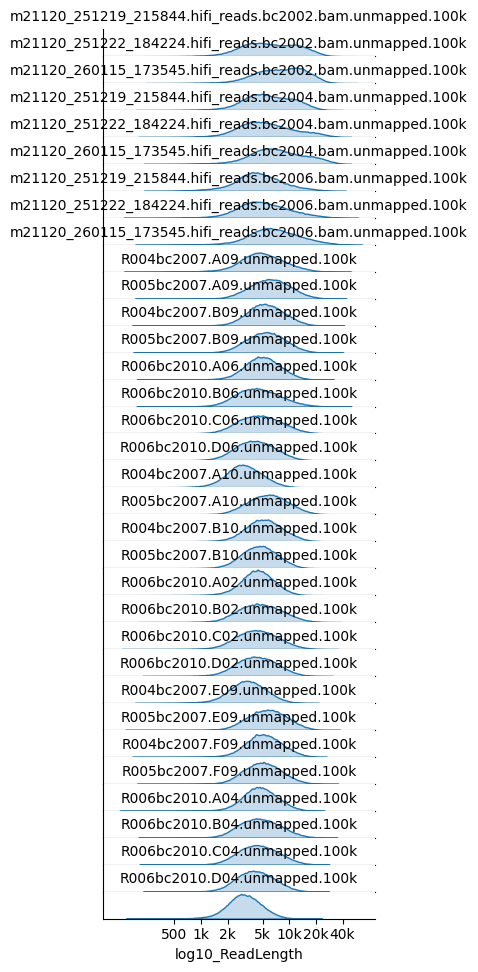

In [63]:
# Sort samples by custom name

sample_order = [
"m21120_251219_215844.hifi_reads.bc2002.bam.unmapped.100k",
"m21120_251222_184224.hifi_reads.bc2002.bam.unmapped.100k",
"m21120_260115_173545.hifi_reads.bc2002.bam.unmapped.100k",
"m21120_251219_215844.hifi_reads.bc2004.bam.unmapped.100k",
"m21120_251222_184224.hifi_reads.bc2004.bam.unmapped.100k",
"m21120_260115_173545.hifi_reads.bc2004.bam.unmapped.100k",
"m21120_251219_215844.hifi_reads.bc2006.bam.unmapped.100k",
"m21120_251222_184224.hifi_reads.bc2006.bam.unmapped.100k",
"m21120_260115_173545.hifi_reads.bc2006.bam.unmapped.100k",
"R004bc2007.A09.unmapped.100k",
"R005bc2007.A09.unmapped.100k",
"R004bc2007.B09.unmapped.100k",
"R005bc2007.B09.unmapped.100k",
"R006bc2010.A06.unmapped.100k",
"R006bc2010.B06.unmapped.100k",
"R006bc2010.C06.unmapped.100k",
"R006bc2010.D06.unmapped.100k",
"R004bc2007.A10.unmapped.100k",
"R005bc2007.A10.unmapped.100k",
"R004bc2007.B10.unmapped.100k",
"R005bc2007.B10.unmapped.100k",
"R006bc2010.A02.unmapped.100k",
"R006bc2010.B02.unmapped.100k",
"R006bc2010.C02.unmapped.100k",
"R006bc2010.D02.unmapped.100k",
"R004bc2007.E09.unmapped.100k",
"R005bc2007.E09.unmapped.100k",
"R004bc2007.F09.unmapped.100k",
"R005bc2007.F09.unmapped.100k",
"R006bc2010.A04.unmapped.100k",
"R006bc2010.B04.unmapped.100k",
"R006bc2010.C04.unmapped.100k",
"R006bc2010.D04.unmapped.100k",
]

# Create ridge plot
g = sns.FacetGrid(
    eed_df,
    row="Sample",
    row_order=sample_order,
    aspect=10,
    height=0.35,
    palette="viridis"
)

g.map(
    sns.kdeplot,
    "log10_ReadLength",
    fill=True,
    bw_adjust=0.3
)

plt.xticks(
    np.log10([500,1000,2000,5000,10000,20000,40000]),
    ["500","1k","2k","5k","10k","20k","40k"]
)

# Overlap the ridges
g.figure.subplots_adjust(hspace=0)

# Remove unnecessary axes
g.set_titles("{row_name}") # this leaves the file names on the plot
#g.set_titles("") # this removes the plot
g.set(yticks=[])
g.set_ylabels("")

plt.show()

/Users/jake_minich/miniforge3/lib/python3.13/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/Users/jake_minich/miniforge3/lib/python3.13/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)


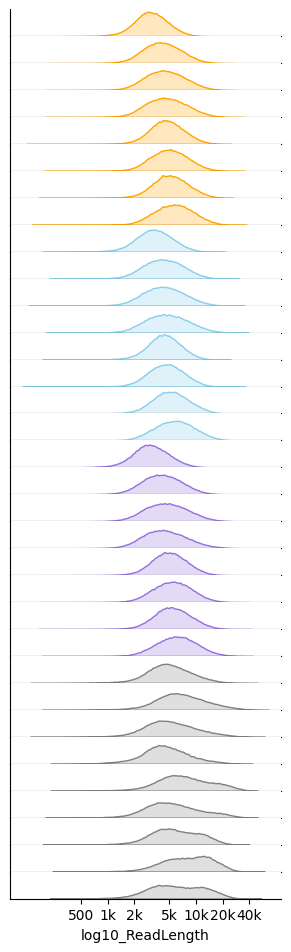

In [70]:
sample_order = [
"m21120_251219_215844.hifi_reads.bc2002.bam.unmapped.100k",
"m21120_251222_184224.hifi_reads.bc2002.bam.unmapped.100k",
"m21120_260115_173545.hifi_reads.bc2002.bam.unmapped.100k",
"m21120_251219_215844.hifi_reads.bc2004.bam.unmapped.100k",
"m21120_251222_184224.hifi_reads.bc2004.bam.unmapped.100k",
"m21120_260115_173545.hifi_reads.bc2004.bam.unmapped.100k",
"m21120_251219_215844.hifi_reads.bc2006.bam.unmapped.100k",
"m21120_251222_184224.hifi_reads.bc2006.bam.unmapped.100k",
"m21120_260115_173545.hifi_reads.bc2006.bam.unmapped.100k",
"R004bc2007.A09.unmapped.100k",
"R005bc2007.A09.unmapped.100k",
"R004bc2007.B09.unmapped.100k",
"R005bc2007.B09.unmapped.100k",
"R006bc2010.A06.unmapped.100k",
"R006bc2010.B06.unmapped.100k",
"R006bc2010.C06.unmapped.100k",
"R006bc2010.D06.unmapped.100k",
"R004bc2007.A10.unmapped.100k",
"R005bc2007.A10.unmapped.100k",
"R004bc2007.B10.unmapped.100k",
"R005bc2007.B10.unmapped.100k",
"R006bc2010.A02.unmapped.100k",
"R006bc2010.B02.unmapped.100k",
"R006bc2010.C02.unmapped.100k",
"R006bc2010.D02.unmapped.100k",
"R004bc2007.E09.unmapped.100k",
"R005bc2007.E09.unmapped.100k",
"R004bc2007.F09.unmapped.100k",
"R005bc2007.F09.unmapped.100k",
"R006bc2010.A04.unmapped.100k",
"R006bc2010.B04.unmapped.100k",
"R006bc2010.C04.unmapped.100k",
"R006bc2010.D04.unmapped.100k",
]

sample_colors = {
    # control
"m21120_251219_215844.hifi_reads.bc2002.bam.unmapped.100k": "grey",
"m21120_251222_184224.hifi_reads.bc2002.bam.unmapped.100k": "grey",
"m21120_260115_173545.hifi_reads.bc2002.bam.unmapped.100k": "grey",
"m21120_251219_215844.hifi_reads.bc2004.bam.unmapped.100k": "grey",
"m21120_251222_184224.hifi_reads.bc2004.bam.unmapped.100k": "grey",
"m21120_260115_173545.hifi_reads.bc2004.bam.unmapped.100k": "grey",
"m21120_251219_215844.hifi_reads.bc2006.bam.unmapped.100k": "grey",
"m21120_251222_184224.hifi_reads.bc2006.bam.unmapped.100k": "grey",
"m21120_260115_173545.hifi_reads.bc2006.bam.unmapped.100k": "grey",
 # Takara
"R004bc2007.A09.unmapped.100k":"mediumpurple",
"R005bc2007.A09.unmapped.100k":"mediumpurple",
"R004bc2007.B09.unmapped.100k":"mediumpurple",
"R005bc2007.B09.unmapped.100k":"mediumpurple",
"R006bc2010.A06.unmapped.100k":"mediumpurple",
"R006bc2010.B06.unmapped.100k":"mediumpurple",
"R006bc2010.C06.unmapped.100k":"mediumpurple",
"R006bc2010.D06.unmapped.100k":"mediumpurple",
 # Kura
"R004bc2007.A10.unmapped.100k": "skyblue",
"R005bc2007.A10.unmapped.100k": "skyblue",
"R004bc2007.B10.unmapped.100k": "skyblue",
"R005bc2007.B10.unmapped.100k": "skyblue",
"R006bc2010.A02.unmapped.100k": "skyblue",
"R006bc2010.B02.unmapped.100k": "skyblue",
"R006bc2010.C02.unmapped.100k": "skyblue",
"R006bc2010.D02.unmapped.100k": "skyblue",
 # NEB    
"R004bc2007.E09.unmapped.100k": "orange",
"R005bc2007.E09.unmapped.100k": "orange",
"R004bc2007.F09.unmapped.100k": "orange",
"R005bc2007.F09.unmapped.100k": "orange",
"R006bc2010.A04.unmapped.100k": "orange",
"R006bc2010.B04.unmapped.100k": "orange",
"R006bc2010.C04.unmapped.100k": "orange",
"R006bc2010.D04.unmapped.100k": "orange",
}
# Create ridge plot
g = sns.FacetGrid(
    eed_df,
    row="Sample",
    row_order=sample_order [::-1],# this does the inverse of the order
    hue="Sample",
    aspect=10,
    height=0.35,
    palette=sample_colors
)

g.map(
    sns.kdeplot,
    "log10_ReadLength",
    fill=True,
    bw_adjust=0.3
)

plt.xticks(
    np.log10([500,1000,2000,5000,10000,20000,40000]),
    ["500","1k","2k","5k","10k","20k","40k"]
)

# Overlap the ridges
g.figure.subplots_adjust(hspace=0)

# Remove unnecessary axes
g.set_titles("{row_name}") # this leaves the file names on the plot
g.set_titles("") # this removes the plot
g.set(yticks=[])
g.set_ylabels("")
plt.savefig("../Figures/EED_ridgeplot.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# Description of figure above
# Ridgeline plots depict the distribution of read lengths for each sample as kernel density estimates calculated from log10-transformed read lengths (bandwidth adjustment = 0.3). X-axis tick labels are shown as the corresponding read lengths (bp) rather than their log10 values. Samples are grouped by library preparation method and colored accordingly.
# Kernel density estimates were computed on the log10-transformed read length distribution to improve visualization across the wide dynamic range of sequencing read lengths.
    

/Users/jake_minich/miniforge3/lib/python3.13/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/Users/jake_minich/miniforge3/lib/python3.13/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)


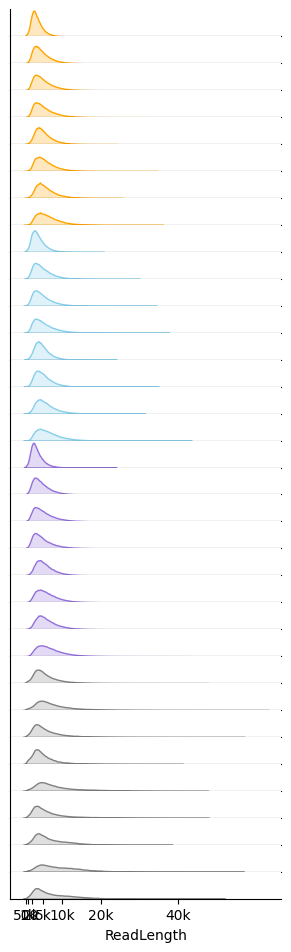

In [72]:
# Repeat as above but remove the log scaled read length

sample_order = [
"m21120_251219_215844.hifi_reads.bc2002.bam.unmapped.100k",
"m21120_251222_184224.hifi_reads.bc2002.bam.unmapped.100k",
"m21120_260115_173545.hifi_reads.bc2002.bam.unmapped.100k",
"m21120_251219_215844.hifi_reads.bc2004.bam.unmapped.100k",
"m21120_251222_184224.hifi_reads.bc2004.bam.unmapped.100k",
"m21120_260115_173545.hifi_reads.bc2004.bam.unmapped.100k",
"m21120_251219_215844.hifi_reads.bc2006.bam.unmapped.100k",
"m21120_251222_184224.hifi_reads.bc2006.bam.unmapped.100k",
"m21120_260115_173545.hifi_reads.bc2006.bam.unmapped.100k",
"R004bc2007.A09.unmapped.100k",
"R005bc2007.A09.unmapped.100k",
"R004bc2007.B09.unmapped.100k",
"R005bc2007.B09.unmapped.100k",
"R006bc2010.A06.unmapped.100k",
"R006bc2010.B06.unmapped.100k",
"R006bc2010.C06.unmapped.100k",
"R006bc2010.D06.unmapped.100k",
"R004bc2007.A10.unmapped.100k",
"R005bc2007.A10.unmapped.100k",
"R004bc2007.B10.unmapped.100k",
"R005bc2007.B10.unmapped.100k",
"R006bc2010.A02.unmapped.100k",
"R006bc2010.B02.unmapped.100k",
"R006bc2010.C02.unmapped.100k",
"R006bc2010.D02.unmapped.100k",
"R004bc2007.E09.unmapped.100k",
"R005bc2007.E09.unmapped.100k",
"R004bc2007.F09.unmapped.100k",
"R005bc2007.F09.unmapped.100k",
"R006bc2010.A04.unmapped.100k",
"R006bc2010.B04.unmapped.100k",
"R006bc2010.C04.unmapped.100k",
"R006bc2010.D04.unmapped.100k",
]

sample_colors = {
    # control
"m21120_251219_215844.hifi_reads.bc2002.bam.unmapped.100k": "grey",
"m21120_251222_184224.hifi_reads.bc2002.bam.unmapped.100k": "grey",
"m21120_260115_173545.hifi_reads.bc2002.bam.unmapped.100k": "grey",
"m21120_251219_215844.hifi_reads.bc2004.bam.unmapped.100k": "grey",
"m21120_251222_184224.hifi_reads.bc2004.bam.unmapped.100k": "grey",
"m21120_260115_173545.hifi_reads.bc2004.bam.unmapped.100k": "grey",
"m21120_251219_215844.hifi_reads.bc2006.bam.unmapped.100k": "grey",
"m21120_251222_184224.hifi_reads.bc2006.bam.unmapped.100k": "grey",
"m21120_260115_173545.hifi_reads.bc2006.bam.unmapped.100k": "grey",
 # Takara
"R004bc2007.A09.unmapped.100k":"mediumpurple",
"R005bc2007.A09.unmapped.100k":"mediumpurple",
"R004bc2007.B09.unmapped.100k":"mediumpurple",
"R005bc2007.B09.unmapped.100k":"mediumpurple",
"R006bc2010.A06.unmapped.100k":"mediumpurple",
"R006bc2010.B06.unmapped.100k":"mediumpurple",
"R006bc2010.C06.unmapped.100k":"mediumpurple",
"R006bc2010.D06.unmapped.100k":"mediumpurple",
 # Kura
"R004bc2007.A10.unmapped.100k": "skyblue",
"R005bc2007.A10.unmapped.100k": "skyblue",
"R004bc2007.B10.unmapped.100k": "skyblue",
"R005bc2007.B10.unmapped.100k": "skyblue",
"R006bc2010.A02.unmapped.100k": "skyblue",
"R006bc2010.B02.unmapped.100k": "skyblue",
"R006bc2010.C02.unmapped.100k": "skyblue",
"R006bc2010.D02.unmapped.100k": "skyblue",
 # NEB    
"R004bc2007.E09.unmapped.100k": "orange",
"R005bc2007.E09.unmapped.100k": "orange",
"R004bc2007.F09.unmapped.100k": "orange",
"R005bc2007.F09.unmapped.100k": "orange",
"R006bc2010.A04.unmapped.100k": "orange",
"R006bc2010.B04.unmapped.100k": "orange",
"R006bc2010.C04.unmapped.100k": "orange",
"R006bc2010.D04.unmapped.100k": "orange",
}
# Create ridge plot
g = sns.FacetGrid(
    eed_df,
    row="Sample",
    row_order=sample_order [::-1],# this does the inverse of the order
    hue="Sample",
    aspect=10,
    height=0.35,
    palette=sample_colors
)

g.map(
    sns.kdeplot,
    "ReadLength", # "log10_ReadLength", for log
    fill=True,
    bw_adjust=0.3
)

plt.xticks(
   [500,1000,2000,5000,10000,20000,40000], # change for log   np.log10([500,1000,2000,5000,10000,20000,40000]),
    ["500","1k","2k","5k","10k","20k","40k"]
)

# Overlap the ridges
g.figure.subplots_adjust(hspace=0)

# Remove unnecessary axes
g.set_titles("{row_name}") # this leaves the file names on the plot
g.set_titles("") # this removes the plot
g.set(yticks=[])
g.set_ylabels("")
#plt.savefig("../Figures/EED_ridgeplot.png", dpi=300, bbox_inches="tight")
plt.show()

In [74]:
## method to obtain data on the read lengths from fastq files
# specific for ESK samples
# Directory containing FASTQ files
esk_fastq_dir = Path("../DATA-PUBLIC/fastq-ESK/")

records = []

for fastq in sorted(esk_fastq_dir.glob("*.fastq")):

    sample = fastq.stem

    with open(fastq) as f:
        while True:
            header = f.readline()
            if not header:
                break

            sequence = f.readline().strip()
            f.readline()        # +
            f.readline()        # quality

            records.append({
                "Sample": sample,
                "ReadLength": len(sequence)
            })

esk_df = pd.DataFrame(records)

print(esk_df.head())
print(esk_df.shape)

                         Sample  ReadLength
0  R004bc2008.C09.unmapped.100k       10104
1  R004bc2008.C09.unmapped.100k        8232
2  R004bc2008.C09.unmapped.100k       11916
3  R004bc2008.C09.unmapped.100k        5233
4  R004bc2008.C09.unmapped.100k        5649
(2365301, 2)


In [75]:
# transform data
esk_df["log10_ReadLength"] = np.log10(esk_df["ReadLength"])

/Users/jake_minich/miniforge3/lib/python3.13/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/Users/jake_minich/miniforge3/lib/python3.13/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)


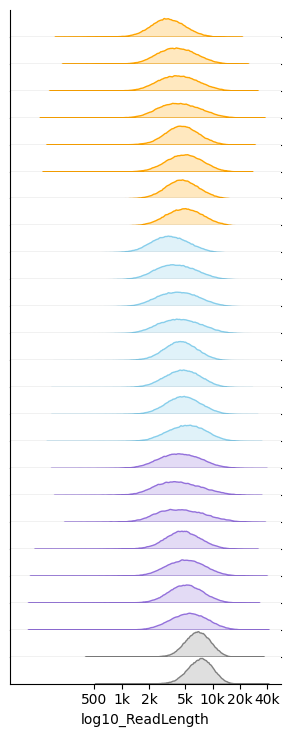

In [77]:
#ESK specific
sample_order = [
"m21120_260113_214725.hifi_reads.bc2009.unmapped.100k",
"m21120_260115_173545.hifi_reads.bc2009.bam.unmapped.100k",
"R004bc2008.C09.unmapped.100k",
"R005bc2008.C09.unmapped.100k",
"R004bc2008.D09.unmapped.100k",
"R005bc2008.D09.unmapped.100k",
"R006bc2010.E06.unmapped.100k",
"R006bc2010.F06.unmapped.100k",
"R006bc2010.G06.unmapped.100k",
"R004bc2008.C10.unmapped.100k",
"R005bc2008.C10.unmapped.100k",
"R004bc2008.D10.unmapped.100k",
"R005bc2008.D10.unmapped.100k",
"R006bc2010.E02.unmapped.100k",
"R006bc2010.F02.unmapped.100k",
"R006bc2010.G02.unmapped.100k",
"R006bc2010.H02.unmapped.100k",
"R004bc2008.G09.unmapped.100k",
"R005bc2008.G09.unmapped.100k",
"R004bc2008.H09.unmapped.100k",
"R005bc2008.H09.unmapped.100k",
"R006bc2010.E04.unmapped.100k",
"R006bc2010.F04.unmapped.100k",
"R006bc2010.G04.unmapped.100k",
"R006bc2010.H04.unmapped.100k",
]

sample_colors = {
 # control
"m21120_260113_214725.hifi_reads.bc2009.unmapped.100k": "grey",
"m21120_260115_173545.hifi_reads.bc2009.bam.unmapped.100k": "grey",
    
 # Takara
"R004bc2008.C09.unmapped.100k":"mediumpurple",
"R005bc2008.C09.unmapped.100k":"mediumpurple",
"R004bc2008.D09.unmapped.100k":"mediumpurple",
"R005bc2008.D09.unmapped.100k":"mediumpurple",
"R006bc2010.E06.unmapped.100k":"mediumpurple",
"R006bc2010.F06.unmapped.100k":"mediumpurple",
"R006bc2010.G06.unmapped.100k":"mediumpurple",
    
 # Kura
"R004bc2008.C10.unmapped.100k": "skyblue",
"R005bc2008.C10.unmapped.100k": "skyblue",
"R004bc2008.D10.unmapped.100k": "skyblue",
"R005bc2008.D10.unmapped.100k": "skyblue",
"R006bc2010.E02.unmapped.100k": "skyblue",
"R006bc2010.F02.unmapped.100k": "skyblue",
"R006bc2010.G02.unmapped.100k": "skyblue",
"R006bc2010.H02.unmapped.100k": "skyblue",

# NEB   
"R004bc2008.G09.unmapped.100k": "orange",
"R005bc2008.G09.unmapped.100k": "orange",
"R004bc2008.H09.unmapped.100k": "orange",
"R005bc2008.H09.unmapped.100k": "orange",
"R006bc2010.E04.unmapped.100k": "orange",
"R006bc2010.F04.unmapped.100k": "orange",
"R006bc2010.G04.unmapped.100k": "orange",
"R006bc2010.H04.unmapped.100k": "orange",
        
}

# Create ridge plot
g = sns.FacetGrid(
    esk_df,
    row="Sample",
    row_order=sample_order [::-1],# this does the inverse of the order
    hue="Sample",
    aspect=10,
    height=0.35,
    palette=sample_colors
)

g.map(
    sns.kdeplot,
    "log10_ReadLength",
    fill=True,
    bw_adjust=0.3
)

plt.xticks(
    np.log10([500,1000,2000,5000,10000,20000,40000]),
    ["500","1k","2k","5k","10k","20k","40k"]
)

# Overlap the ridges
g.figure.subplots_adjust(hspace=0)

# Remove unnecessary axes
g.set_titles("{row_name}") # this leaves the file names on the plot
g.set_titles("") # this removes the plot
g.set(yticks=[])
g.set_ylabels("")
plt.savefig("../Figures/ESK_ridgeplot.png", dpi=300, bbox_inches="tight")
plt.show()

In [78]:
## Calculate the total counts of reads (out of 100,000) which are greater than 5000 for each sample across all samples

In [83]:
summary = (
    esk_df.groupby("Sample")["ReadLength"]
      .agg(
          TotalReads="count",
          Mean="mean",
          Median="median",
          Max="max",
          Reads_GT_5000=lambda x: (x > 5000).sum(),
          Reads_GT_10000=lambda x: (x > 10000).sum(),
          Reads_GT_20000=lambda x: (x > 20000).sum(),
      )
)

summary["Pct_GT_5000"] = (
    100 * summary["Reads_GT_5000"] / summary["TotalReads"]
).round(1)

summary["Pct_GT_10000"] = (
    100 * summary["Reads_GT_10000"] / summary["TotalReads"]
).round(1)

summary

,TotalReads,Mean,Median,Max,Reads_GT_5000,Reads_GT_10000,Reads_GT_20000,Pct_GT_5000,Pct_GT_10000
Sample,,,,,,,,,
R004bc2008.C09.unmapped.100k,100000,6075.821240,5444.0,39752,56880,10130,270,56.9,10.1
R004bc2008.C10.unmapped.100k,100000,5719.704520,5138.0,33192,52084,8023,136,52.1,8.0
R004bc2008.D09.unmapped.100k,100000,5596.887300,4971.0,38008,49554,7738,207,49.6,7.7
R004bc2008.D10.unmapped.100k,100000,5083.040170,4618.0,26223,43139,4098,31,43.1,4.1
R004bc2008.G09.unmapped.100k,100000,5365.650920,4831.0,33980,47029,5943,31,47.0,5.9
R004bc2008.H09.unmapped.100k,100000,5336.640520,4823.0,26307,46991,5455,42,47.0,5.5
R005bc2008.C09.unmapped.100k,100000,5501.847960,4991.0,31456,49851,6078,58,49.9,6.1
R005bc2008.C10.unmapped.100k,100000,5187.722910,4688.5,30032,44334,4755,49,44.3,4.8
R005bc2008.D09.unmapped.100k,100000,5116.452480,4609.0,30233,42881,4707,52,42.9,4.7


In [84]:
# Summary table for complex fecal sample 'EED'
summary = (
    eed_df.groupby("Sample")["ReadLength"]
      .agg(
          TotalReads="count",
          Mean="mean",
          Median="median",
          Max="max",
          Reads_GT_5000=lambda x: (x > 5000).sum(),
          Reads_GT_10000=lambda x: (x > 10000).sum(),
          Reads_GT_20000=lambda x: (x > 20000).sum(),
      )
)

summary["Pct_GT_5000"] = (
    100 * summary["Reads_GT_5000"] / summary["TotalReads"]
).round(1)

summary["Pct_GT_10000"] = (
    100 * summary["Reads_GT_10000"] / summary["TotalReads"]
).round(1)

summary

,TotalReads,Mean,Median,Max,Reads_GT_5000,Reads_GT_10000,Reads_GT_20000,Pct_GT_5000,Pct_GT_10000
Sample,,,,,,,,,
R004bc2007.A09.unmapped.100k,100000,6929.689500,6036.0,42558,63550,17194,1148,63.6,17.2
R004bc2007.A10.unmapped.100k,100000,6512.113670,5712.0,43141,59579,14320,641,59.6,14.3
R004bc2007.B09.unmapped.100k,100000,6096.146580,5394.5,39044,55802,11016,325,55.8,11.0
R004bc2007.B10.unmapped.100k,100000,5064.147070,4565.0,34755,42358,4489,47,42.4,4.5
R004bc2007.E09.unmapped.100k,100000,6309.106940,5609.0,35910,58558,12723,167,58.6,12.7
R004bc2007.F09.unmapped.100k,100000,5598.512120,4961.0,34320,49371,7837,152,49.4,7.8
R005bc2007.A09.unmapped.100k,100000,6071.763910,5353.0,40240,55645,10677,321,55.6,10.7
R005bc2007.A10.unmapped.100k,100000,5789.558970,5145.0,31118,52283,8841,209,52.3,8.8
R005bc2007.B09.unmapped.100k,100000,5505.274910,4945.0,30644,49051,6602,88,49.1,6.6


In [111]:
ls

2026-03-16_longplex-results.ipynb  Diversity_analysis.ipynb
2026-03-17_longplex_success.ipynb  PB_cost-analysis_v2.ipynb
2026-03-18_mastermix-bias.ipynb    PB_cost-analysis.ipynb
2026-04-03_hifi.ipynb              RLH_revision.ipynb


In [169]:
sample_info=pd.read_csv("../Data_files/sample_info_2026-07-31_with_features.csv")

In [170]:
sample_info.head()

,sample_name,order_rlh,name_short_2,filename,filename_100k,TotalReads,py_100k_Mean,py_100k_Median,py_100k_Max,py_100k_Reads_GT_5000,...,r__Varidnaviria|k__Bamfordvirae|p__Nucleocytoviricota|c__Megaviricetes|o__Algavirales|UNKNOWN|UNKNOWN|UNKNOWN|t__IMGVR_UViG_2667527633_000003,r__Varidnaviria|k__Bamfordvirae|p__Preplasmiviricota|c__Tectiliviricetes|o__Rowavirales|f__Adenoviridae|UNKNOWN|UNKNOWN|t__IMGVR_UViG_3300029029_000019,r__Varidnaviria|k__Bamfordvirae|p__Preplasmiviricota|c__Tectiliviricetes|o__Rowavirales|f__Adenoviridae|UNKNOWN|UNKNOWN|t__IMGVR_UViG_3300045988_179509,r__Varidnaviria|k__Bamfordvirae|p__Preplasmiviricota|c__Tectiliviricetes|o__Rowavirales|f__Adenoviridae|UNKNOWN|UNKNOWN|t__IMGVR_UViG_3300045988_179924,r__Varidnaviria|k__Bamfordvirae|p__Preplasmiviricota|c__Tectiliviricetes|o__Rowavirales|f__Adenoviridae|UNKNOWN|UNKNOWN|t__IMGVR_UViG_3300045988_182128,r__Varidnaviria|k__Bamfordvirae|p__Preplasmiviricota|c__Tectiliviricetes|o__Rowavirales|f__Adenoviridae|UNKNOWN|UNKNOWN|t__IMGVR_UViG_3300045988_182499,r__Varidnaviria|k__Bamfordvirae|p__Preplasmiviricota|c__Tectiliviricetes|o__Rowavirales|f__Adenoviridae|g__Mastadenovirus|s__Human mastadenovirus A|t__IMGVR_UViG_638276190_000001,r__Varidnaviria|k__Bamfordvirae|p__Preplasmiviricota|c__Tectiliviricetes|o__Rowavirales|f__Adenoviridae|g__Mastadenovirus|s__Human mastadenovirus B|t__IMGVR_UViG_638276195_000001,r__Varidnaviria|k__Bamfordvirae|p__Preplasmiviricota|c__Tectiliviricetes|o__Rowavirales|f__Adenoviridae|g__Mastadenovirus|s__Human mastadenovirus D|t__IMGVR_UViG_638276191_000001,r__Varidnaviria|k__Bamfordvirae|p__Preplasmiviricota|c__Tectiliviricetes|o__Rowavirales|f__Adenoviridae|g__Mastadenovirus|s__Human mastadenovirus F|t__IMGVR_UViG_638276187_000001
0,m21120.251219.215844.hifi.reads.bc2002.bam,1.0,EED_3000ng_gtube_PCRfree,m21120_251219_215844.hifi_reads.bc2002.bam,m21120_251219_215844.hifi_reads.bc2002.bam.unm...,100000.0,7627.45917,5898.0,51618.0,57818.0,...,0.0000,0.0,0.0,0.0663,0.0000,0.0,0.0900,0.0,0.0000,0.1650
1,m21120.251219.215844.hifi.reads.bc2004.bam,4.0,EED_3000ng_pipetdil_PCRfree,m21120_251219_215844.hifi_reads.bc2004.bam,m21120_251219_215844.hifi_reads.bc2004.bam.unm...,100000.0,7115.37821,5140.0,47457.0,51561.0,...,0.0000,0.0,0.0,0.0829,0.1628,0.0,0.0000,0.0,0.0000,0.0000
2,m21120.251219.215844.hifi.reads.bc2006.bam,7.0,EED_3000ng_pipetconc_PCRfree,m21120_251219_215844.hifi_reads.bc2006.bam,m21120_251219_215844.hifi_reads.bc2006.bam.unm...,100000.0,6484.09669,4885.0,56710.0,48614.0,...,0.0000,0.0,0.0,0.0000,0.0000,0.0,0.1027,0.0,0.0000,0.0000
3,m21120.251222.184224.hifi.reads.bc2002.bam,2.0,EED_3000ng_gtube_PCRfree,m21120_251222_184224.hifi_reads.bc2002.bam,m21120_251222_184224.hifi_reads.bc2002.bam.unm...,100000.0,9444.55047,8167.0,56509.0,74566.0,...,0.0749,0.0,0.0,0.0000,0.0000,0.0,0.0000,0.0,0.0229,0.0718
4,m21120.251222.184224.hifi.reads.bc2004.bam,5.0,EED_3000ng_pipetdil_PCRfree,m21120_251222_184224.hifi_reads.bc2004.bam,m21120_251222_184224.hifi_reads.bc2004.bam.unm...,100000.0,9175.58737,6963.0,47189.0,69152.0,...,0.0756,0.0,0.0,0.0000,0.0000,0.0,0.0227,0.0,0.0000,0.0000


In [171]:
#style for figures
#sns.set_theme(font_scale=.75)
sns.set_style("whitegrid")
custom_colors={
    "control":"grey",
    "Takara PrimeSTAR LongSeq":"mediumpurple", 
    "NEB Q5 XT": "orange",
    "Kura Decodifi" : "skyblue"}

In [172]:
#splits dataframe into two dataframes for each mock community
eed=sample_info.loc[sample_info["origin"]=="EED fecal"]
esk=sample_info.loc[sample_info["origin"]=="ESK pathogen"]

In [173]:
eed.head()

,sample_name,order_rlh,name_short_2,filename,filename_100k,TotalReads,py_100k_Mean,py_100k_Median,py_100k_Max,py_100k_Reads_GT_5000,...,r__Varidnaviria|k__Bamfordvirae|p__Nucleocytoviricota|c__Megaviricetes|o__Algavirales|UNKNOWN|UNKNOWN|UNKNOWN|t__IMGVR_UViG_2667527633_000003,r__Varidnaviria|k__Bamfordvirae|p__Preplasmiviricota|c__Tectiliviricetes|o__Rowavirales|f__Adenoviridae|UNKNOWN|UNKNOWN|t__IMGVR_UViG_3300029029_000019,r__Varidnaviria|k__Bamfordvirae|p__Preplasmiviricota|c__Tectiliviricetes|o__Rowavirales|f__Adenoviridae|UNKNOWN|UNKNOWN|t__IMGVR_UViG_3300045988_179509,r__Varidnaviria|k__Bamfordvirae|p__Preplasmiviricota|c__Tectiliviricetes|o__Rowavirales|f__Adenoviridae|UNKNOWN|UNKNOWN|t__IMGVR_UViG_3300045988_179924,r__Varidnaviria|k__Bamfordvirae|p__Preplasmiviricota|c__Tectiliviricetes|o__Rowavirales|f__Adenoviridae|UNKNOWN|UNKNOWN|t__IMGVR_UViG_3300045988_182128,r__Varidnaviria|k__Bamfordvirae|p__Preplasmiviricota|c__Tectiliviricetes|o__Rowavirales|f__Adenoviridae|UNKNOWN|UNKNOWN|t__IMGVR_UViG_3300045988_182499,r__Varidnaviria|k__Bamfordvirae|p__Preplasmiviricota|c__Tectiliviricetes|o__Rowavirales|f__Adenoviridae|g__Mastadenovirus|s__Human mastadenovirus A|t__IMGVR_UViG_638276190_000001,r__Varidnaviria|k__Bamfordvirae|p__Preplasmiviricota|c__Tectiliviricetes|o__Rowavirales|f__Adenoviridae|g__Mastadenovirus|s__Human mastadenovirus B|t__IMGVR_UViG_638276195_000001,r__Varidnaviria|k__Bamfordvirae|p__Preplasmiviricota|c__Tectiliviricetes|o__Rowavirales|f__Adenoviridae|g__Mastadenovirus|s__Human mastadenovirus D|t__IMGVR_UViG_638276191_000001,r__Varidnaviria|k__Bamfordvirae|p__Preplasmiviricota|c__Tectiliviricetes|o__Rowavirales|f__Adenoviridae|g__Mastadenovirus|s__Human mastadenovirus F|t__IMGVR_UViG_638276187_000001
0,m21120.251219.215844.hifi.reads.bc2002.bam,1.0,EED_3000ng_gtube_PCRfree,m21120_251219_215844.hifi_reads.bc2002.bam,m21120_251219_215844.hifi_reads.bc2002.bam.unm...,100000.0,7627.45917,5898.0,51618.0,57818.0,...,0.0000,0.0,0.0,0.0663,0.0000,0.0,0.0900,0.0,0.0000,0.1650
1,m21120.251219.215844.hifi.reads.bc2004.bam,4.0,EED_3000ng_pipetdil_PCRfree,m21120_251219_215844.hifi_reads.bc2004.bam,m21120_251219_215844.hifi_reads.bc2004.bam.unm...,100000.0,7115.37821,5140.0,47457.0,51561.0,...,0.0000,0.0,0.0,0.0829,0.1628,0.0,0.0000,0.0,0.0000,0.0000
2,m21120.251219.215844.hifi.reads.bc2006.bam,7.0,EED_3000ng_pipetconc_PCRfree,m21120_251219_215844.hifi_reads.bc2006.bam,m21120_251219_215844.hifi_reads.bc2006.bam.unm...,100000.0,6484.09669,4885.0,56710.0,48614.0,...,0.0000,0.0,0.0,0.0000,0.0000,0.0,0.1027,0.0,0.0000,0.0000
3,m21120.251222.184224.hifi.reads.bc2002.bam,2.0,EED_3000ng_gtube_PCRfree,m21120_251222_184224.hifi_reads.bc2002.bam,m21120_251222_184224.hifi_reads.bc2002.bam.unm...,100000.0,9444.55047,8167.0,56509.0,74566.0,...,0.0749,0.0,0.0,0.0000,0.0000,0.0,0.0000,0.0,0.0229,0.0718
4,m21120.251222.184224.hifi.reads.bc2004.bam,5.0,EED_3000ng_pipetdil_PCRfree,m21120_251222_184224.hifi_reads.bc2004.bam,m21120_251222_184224.hifi_reads.bc2004.bam.unm...,100000.0,9175.58737,6963.0,47189.0,69152.0,...,0.0756,0.0,0.0,0.0000,0.0000,0.0,0.0227,0.0,0.0000,0.0000


In [174]:
# remove all samples that went through Qiagen cleanup so as to not confound
eed_q=eed.loc[eed["qiagen_cleanup"]==False]
esk_q=esk.loc[esk["qiagen_cleanup"]==False]
eed_q.head()

,sample_name,order_rlh,name_short_2,filename,filename_100k,TotalReads,py_100k_Mean,py_100k_Median,py_100k_Max,py_100k_Reads_GT_5000,...,r__Varidnaviria|k__Bamfordvirae|p__Nucleocytoviricota|c__Megaviricetes|o__Algavirales|UNKNOWN|UNKNOWN|UNKNOWN|t__IMGVR_UViG_2667527633_000003,r__Varidnaviria|k__Bamfordvirae|p__Preplasmiviricota|c__Tectiliviricetes|o__Rowavirales|f__Adenoviridae|UNKNOWN|UNKNOWN|t__IMGVR_UViG_3300029029_000019,r__Varidnaviria|k__Bamfordvirae|p__Preplasmiviricota|c__Tectiliviricetes|o__Rowavirales|f__Adenoviridae|UNKNOWN|UNKNOWN|t__IMGVR_UViG_3300045988_179509,r__Varidnaviria|k__Bamfordvirae|p__Preplasmiviricota|c__Tectiliviricetes|o__Rowavirales|f__Adenoviridae|UNKNOWN|UNKNOWN|t__IMGVR_UViG_3300045988_179924,r__Varidnaviria|k__Bamfordvirae|p__Preplasmiviricota|c__Tectiliviricetes|o__Rowavirales|f__Adenoviridae|UNKNOWN|UNKNOWN|t__IMGVR_UViG_3300045988_182128,r__Varidnaviria|k__Bamfordvirae|p__Preplasmiviricota|c__Tectiliviricetes|o__Rowavirales|f__Adenoviridae|UNKNOWN|UNKNOWN|t__IMGVR_UViG_3300045988_182499,r__Varidnaviria|k__Bamfordvirae|p__Preplasmiviricota|c__Tectiliviricetes|o__Rowavirales|f__Adenoviridae|g__Mastadenovirus|s__Human mastadenovirus A|t__IMGVR_UViG_638276190_000001,r__Varidnaviria|k__Bamfordvirae|p__Preplasmiviricota|c__Tectiliviricetes|o__Rowavirales|f__Adenoviridae|g__Mastadenovirus|s__Human mastadenovirus B|t__IMGVR_UViG_638276195_000001,r__Varidnaviria|k__Bamfordvirae|p__Preplasmiviricota|c__Tectiliviricetes|o__Rowavirales|f__Adenoviridae|g__Mastadenovirus|s__Human mastadenovirus D|t__IMGVR_UViG_638276191_000001,r__Varidnaviria|k__Bamfordvirae|p__Preplasmiviricota|c__Tectiliviricetes|o__Rowavirales|f__Adenoviridae|g__Mastadenovirus|s__Human mastadenovirus F|t__IMGVR_UViG_638276187_000001
0,m21120.251219.215844.hifi.reads.bc2002.bam,1.0,EED_3000ng_gtube_PCRfree,m21120_251219_215844.hifi_reads.bc2002.bam,m21120_251219_215844.hifi_reads.bc2002.bam.unm...,100000.0,7627.45917,5898.0,51618.0,57818.0,...,0.0000,0.0,0.0,0.0663,0.0000,0.0,0.0900,0.0,0.0000,0.1650
1,m21120.251219.215844.hifi.reads.bc2004.bam,4.0,EED_3000ng_pipetdil_PCRfree,m21120_251219_215844.hifi_reads.bc2004.bam,m21120_251219_215844.hifi_reads.bc2004.bam.unm...,100000.0,7115.37821,5140.0,47457.0,51561.0,...,0.0000,0.0,0.0,0.0829,0.1628,0.0,0.0000,0.0,0.0000,0.0000
2,m21120.251219.215844.hifi.reads.bc2006.bam,7.0,EED_3000ng_pipetconc_PCRfree,m21120_251219_215844.hifi_reads.bc2006.bam,m21120_251219_215844.hifi_reads.bc2006.bam.unm...,100000.0,6484.09669,4885.0,56710.0,48614.0,...,0.0000,0.0,0.0,0.0000,0.0000,0.0,0.1027,0.0,0.0000,0.0000
3,m21120.251222.184224.hifi.reads.bc2002.bam,2.0,EED_3000ng_gtube_PCRfree,m21120_251222_184224.hifi_reads.bc2002.bam,m21120_251222_184224.hifi_reads.bc2002.bam.unm...,100000.0,9444.55047,8167.0,56509.0,74566.0,...,0.0749,0.0,0.0,0.0000,0.0000,0.0,0.0000,0.0,0.0229,0.0718
4,m21120.251222.184224.hifi.reads.bc2004.bam,5.0,EED_3000ng_pipetdil_PCRfree,m21120_251222_184224.hifi_reads.bc2004.bam,m21120_251222_184224.hifi_reads.bc2004.bam.unm...,100000.0,9175.58737,6963.0,47189.0,69152.0,...,0.0756,0.0,0.0,0.0000,0.0000,0.0,0.0227,0.0,0.0000,0.0000


In [175]:
# remove all samples that have less than 100k reads <includes Qiagen>
eed_nt=eed_q.loc[eed["reads_g100k"]==1]
esk_nt=esk_q.loc[esk["reads_g100k"]==1]

In [176]:
#sorting samples to ensure they are plotted correctly with optimal colors
esk_nt_sort=esk_nt.sort_values(by="name_short_4", ascending=False)
eed_nt_sort=eed_nt.sort_values(by="name_short_4", ascending=False)

In [177]:
eed_nt_sort.head()

,sample_name,order_rlh,name_short_2,filename,filename_100k,TotalReads,py_100k_Mean,py_100k_Median,py_100k_Max,py_100k_Reads_GT_5000,...,r__Varidnaviria|k__Bamfordvirae|p__Nucleocytoviricota|c__Megaviricetes|o__Algavirales|UNKNOWN|UNKNOWN|UNKNOWN|t__IMGVR_UViG_2667527633_000003,r__Varidnaviria|k__Bamfordvirae|p__Preplasmiviricota|c__Tectiliviricetes|o__Rowavirales|f__Adenoviridae|UNKNOWN|UNKNOWN|t__IMGVR_UViG_3300029029_000019,r__Varidnaviria|k__Bamfordvirae|p__Preplasmiviricota|c__Tectiliviricetes|o__Rowavirales|f__Adenoviridae|UNKNOWN|UNKNOWN|t__IMGVR_UViG_3300045988_179509,r__Varidnaviria|k__Bamfordvirae|p__Preplasmiviricota|c__Tectiliviricetes|o__Rowavirales|f__Adenoviridae|UNKNOWN|UNKNOWN|t__IMGVR_UViG_3300045988_179924,r__Varidnaviria|k__Bamfordvirae|p__Preplasmiviricota|c__Tectiliviricetes|o__Rowavirales|f__Adenoviridae|UNKNOWN|UNKNOWN|t__IMGVR_UViG_3300045988_182128,r__Varidnaviria|k__Bamfordvirae|p__Preplasmiviricota|c__Tectiliviricetes|o__Rowavirales|f__Adenoviridae|UNKNOWN|UNKNOWN|t__IMGVR_UViG_3300045988_182499,r__Varidnaviria|k__Bamfordvirae|p__Preplasmiviricota|c__Tectiliviricetes|o__Rowavirales|f__Adenoviridae|g__Mastadenovirus|s__Human mastadenovirus A|t__IMGVR_UViG_638276190_000001,r__Varidnaviria|k__Bamfordvirae|p__Preplasmiviricota|c__Tectiliviricetes|o__Rowavirales|f__Adenoviridae|g__Mastadenovirus|s__Human mastadenovirus B|t__IMGVR_UViG_638276195_000001,r__Varidnaviria|k__Bamfordvirae|p__Preplasmiviricota|c__Tectiliviricetes|o__Rowavirales|f__Adenoviridae|g__Mastadenovirus|s__Human mastadenovirus D|t__IMGVR_UViG_638276191_000001,r__Varidnaviria|k__Bamfordvirae|p__Preplasmiviricota|c__Tectiliviricetes|o__Rowavirales|f__Adenoviridae|g__Mastadenovirus|s__Human mastadenovirus F|t__IMGVR_UViG_638276187_000001
1,m21120.251219.215844.hifi.reads.bc2004.bam,4.0,EED_3000ng_pipetdil_PCRfree,m21120_251219_215844.hifi_reads.bc2004.bam,m21120_251219_215844.hifi_reads.bc2004.bam.unm...,100000.0,7115.37821,5140.0,47457.0,51561.0,...,0.0000,0.0,0.0,0.0829,0.1628,0.0,0.0000,0.0,0.0,0.000
4,m21120.251222.184224.hifi.reads.bc2004.bam,5.0,EED_3000ng_pipetdil_PCRfree,m21120_251222_184224.hifi_reads.bc2004.bam,m21120_251222_184224.hifi_reads.bc2004.bam.unm...,100000.0,9175.58737,6963.0,47189.0,69152.0,...,0.0756,0.0,0.0,0.0000,0.0000,0.0,0.0227,0.0,0.0,0.000
2,m21120.251219.215844.hifi.reads.bc2006.bam,7.0,EED_3000ng_pipetconc_PCRfree,m21120_251219_215844.hifi_reads.bc2006.bam,m21120_251219_215844.hifi_reads.bc2006.bam.unm...,100000.0,6484.09669,4885.0,56710.0,48614.0,...,0.0000,0.0,0.0,0.0000,0.0000,0.0,0.1027,0.0,0.0,0.000
5,m21120.251222.184224.hifi.reads.bc2006.bam,8.0,EED_3000ng_pipetconc_PCRfree,m21120_251222_184224.hifi_reads.bc2006.bam,m21120_251222_184224.hifi_reads.bc2006.bam.unm...,100000.0,8391.90584,6508.0,62875.0,66401.0,...,0.0000,0.0,0.0,0.0438,0.0000,0.0,0.0148,0.0,0.0,0.000
0,m21120.251219.215844.hifi.reads.bc2002.bam,1.0,EED_3000ng_gtube_PCRfree,m21120_251219_215844.hifi_reads.bc2002.bam,m21120_251219_215844.hifi_reads.bc2002.bam.unm...,100000.0,7627.45917,5898.0,51618.0,57818.0,...,0.0000,0.0,0.0,0.0663,0.0000,0.0,0.0900,0.0,0.0,0.165


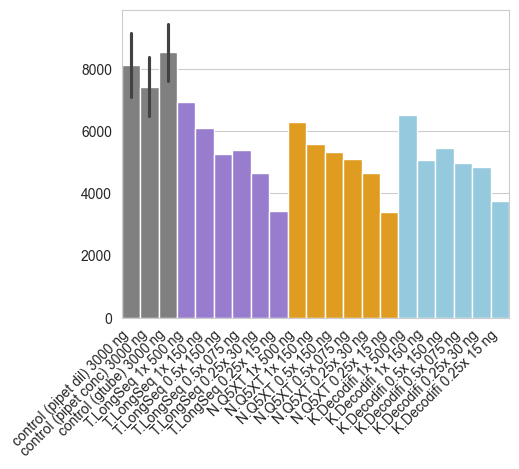

In [263]:
# EED mean
plt.figure(figsize=(5, 4))
ax=sns.barplot(data=eed_nt_sort, x="name_short_4", y="py_100k_Mean", hue="mastermix", palette=custom_colors, legend=False, width=1)
ax.set(xlabel=None)
#ax.set_ylim(0,100)
#ax.set(ylabel="Mean read length bp")
ax.set(ylabel=None)
plt.xticks(rotation=45, ha="right")
plt.show
plt.savefig("../Figures/EED_meanRL.png", dpi=300, bbox_inches='tight')

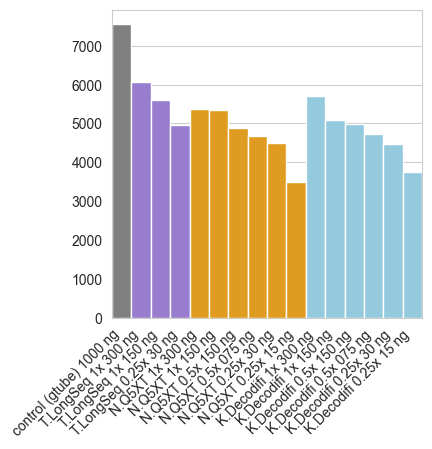

In [264]:
# ESK mean read length
plt.figure(figsize=(4, 4))
ax=sns.barplot(data=esk_nt_sort, x="name_short_4", y="py_100k_Mean", hue="mastermix", palette=custom_colors, legend=False, width=1)
ax.set(xlabel=None)
ax.set(ylabel=None)
#ax.set(ylabel="Mean read length bp")
plt.xticks(rotation=45, ha="right")
plt.show
plt.savefig("../Figures/ESK_meanRL.png", dpi=300, bbox_inches='tight')

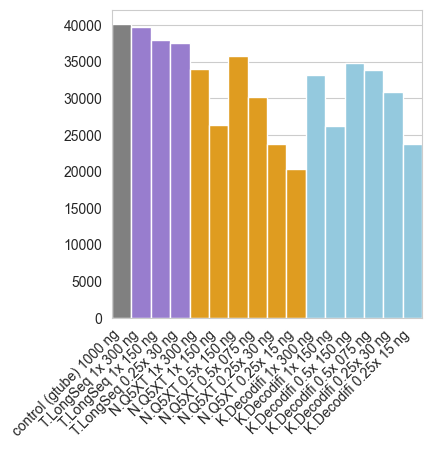

In [257]:
# ESK max
plt.figure(figsize=(4, 4))
ax=sns.barplot(data=esk_nt_sort, x="name_short_4", y="py_100k_Max", hue="mastermix", palette=custom_colors, legend=False, width=1)
ax.set(xlabel=None)
#ax.set_ylim(0,100)
#ax.set(ylabel="Max read length bp ESK")
ax.set(ylabel=None)
plt.xticks(rotation=45, ha="right")
plt.show
plt.savefig("../Figures/ESK_max.png", dpi=300, bbox_inches='tight')

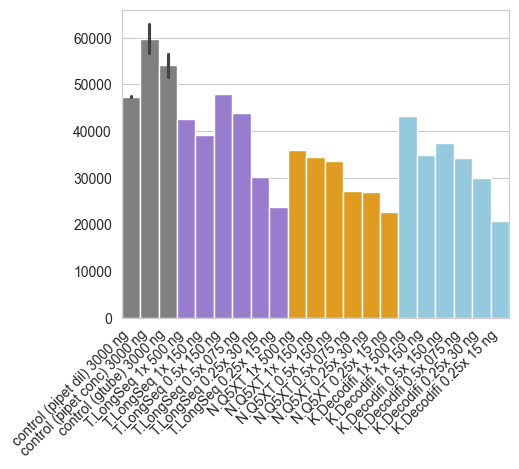

In [258]:
# EED max
plt.figure(figsize=(5, 4))
ax=sns.barplot(data=eed_nt_sort, x="name_short_4", y="py_100k_Max", hue="mastermix", palette=custom_colors, legend=False, width=1)
ax.set(xlabel=None)
#ax.set_ylim(0,100)
#ax.set(ylabel="Max read length bp fecal")
ax.set(ylabel=None)
plt.xticks(rotation=45, ha="right")
plt.show
plt.savefig("../Figures/EED_max.png", dpi=300, bbox_inches='tight')

In [ ]:
# Metrics to do correlations for {
dna_input_ng ~
sub100k_number_of_Mbp
sub100k_mean_read_length
py_100k_Pct_GT_5000
richness_bacteria_sylph_r232_observed_features	
richness_viral_sylph_r232_observed_features	}

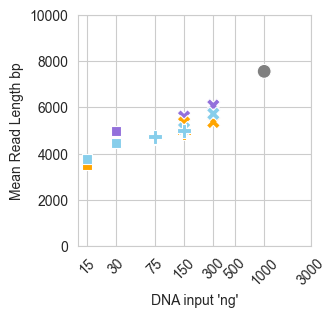

In [228]:
# Impact of DNA input on mean RL for ESK
plt.figure(figsize=(3, 3))
ax=sns.scatterplot(data=esk_nt_sort, 
                   x="dna_input_ng", 
                   y="sub100k_mean_read_length", 
                   hue="mastermix", 
                   style="longplex_rxn2",
                   s=100,
                   palette=custom_colors,legend=False)
ax.set(xlabel="DNA input 'ng'")
ax.set_xscale("log")
ax.set(ylabel="Mean Read Length bp")
plt.xticks(
   ([15,30,75,150,300,500,1000,3000]),
    ["15","30","75","150","300","500","1000","3000"]
)
plt.ylim(0,10000)
plt.xticks(rotation=45, ha="center")
plt.show
plt.savefig("../Figures/ESK_dna~meanRL.png", dpi=300, bbox_inches='tight')

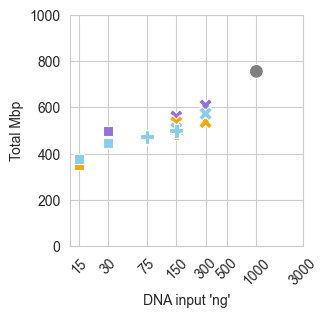

In [227]:
# Impact of DNA input on total yield for ESK
plt.figure(figsize=(3, 3))
ax=sns.scatterplot(data=esk_nt_sort, 
                   x="dna_input_ng", 
                   y="sub100k_number_of_Mbp", 
                   hue="mastermix", 
                   style="longplex_rxn2",
                   s=100,
                   palette=custom_colors,legend=False)
ax.set(xlabel="DNA input 'ng'")
ax.set_xscale("log")
ax.set(ylabel="Total Mbp")
plt.xticks(
   ([15,30,75,150,300,500,1000,3000]),
    ["15","30","75","150","300","500","1000","3000"]
)
plt.ylim(0,1000)
plt.xticks(rotation=45, ha="center")
plt.show
plt.savefig("../Figures/ESK_dna~Mbp.png", dpi=300, bbox_inches='tight')

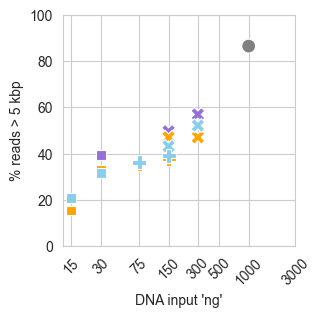

In [223]:
# Impact of DNA input on % reads greater than 5 kb for ESK
plt.figure(figsize=(3, 3))
ax=sns.scatterplot(data=esk_nt_sort, 
                   x="dna_input_ng", 
                   y="py_100k_Pct_GT_5000", 
                   hue="mastermix", 
                   style="longplex_rxn2",
                   s=100,
                   palette=custom_colors,legend=False)
ax.set(xlabel="DNA input 'ng'")
ax.set_xscale("log")
ax.set(ylabel="% reads > 5 kbp")
plt.xticks(
   ([15,30,75,150,300,500,1000,3000]),
    ["15","30","75","150","300","500","1000","3000"]
)
plt.ylim(0,100)
plt.xticks(rotation=45, ha="center")
plt.show
plt.savefig("../Figures/ESK_dna~Pct>5kb.png", dpi=300, bbox_inches='tight')

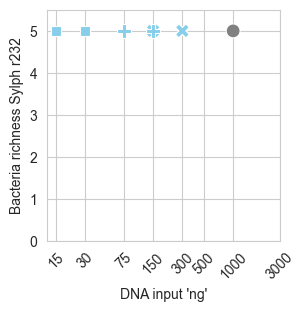

In [234]:
# Impact of DNA input on bacteria richness ESK
plt.figure(figsize=(3, 3))
ax=sns.scatterplot(data=esk_nt_sort, 
                   x="dna_input_ng", 
                   y="richness_bacteria_sylph_r232_observed_features", 
                   hue="mastermix", 
                   style="longplex_rxn2",
                   s=100,
                   palette=custom_colors,legend=False)
ax.set(xlabel="DNA input 'ng'")
ax.set_xscale("log")
ax.set(ylabel="Bacteria richness Sylph r232")
plt.xticks(
   ([15,30,75,150,300,500,1000,3000]),
    ["15","30","75","150","300","500","1000","3000"]
)
plt.ylim(0,5.5)
plt.xticks(rotation=45, ha="center")
plt.show
plt.savefig("../Figures/ESK_dna~Bac-richness.png", dpi=300, bbox_inches='tight')

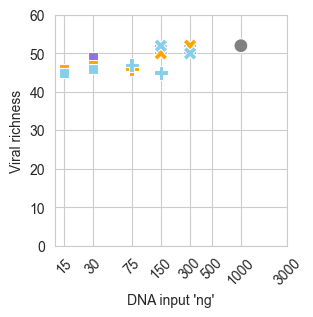

In [213]:
# Impact of DNA input on viral richness ESK
plt.figure(figsize=(3, 3))
ax=sns.scatterplot(data=esk_nt_sort, 
                   x="dna_input_ng", 
                   y="richness_viral_sylph_r232_observed_features", 
                   hue="mastermix", 
                   style="longplex_rxn2",
                   s=100,
                   palette=custom_colors,legend=False)
ax.set(xlabel="DNA input 'ng'")
ax.set_xscale("log")
ax.set(ylabel="Viral richness")
plt.xticks(
   ([15,30,75,150,300,500,1000,3000]),
    ["15","30","75","150","300","500","1000","3000"]
)
plt.ylim(0,60)
plt.xticks(rotation=45, ha="center")
plt.show
plt.savefig("../Figures/ESK_dna~viral-richness.png", dpi=300, bbox_inches='tight')

In [ ]:
##### EED samples now

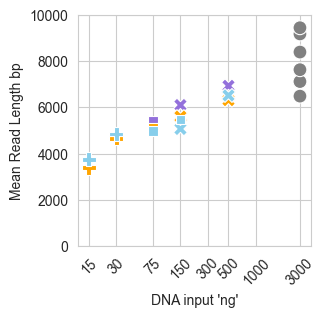

In [237]:
# Impact of DNA input on mean RL on EED
plt.figure(figsize=(3, 3))
ax=sns.scatterplot(data=eed_nt_sort, 
                   x="dna_input_ng", 
                   y="sub100k_mean_read_length", 
                   hue="mastermix", 
                   style="longplex_rxn2",
                   s=100,
                   palette=custom_colors,legend=False)
ax.set(xlabel="DNA input 'ng'")
ax.set_xscale("log")
#ax.set_ylim(0,100)
ax.set(ylabel="Mean Read Length bp")
plt.xticks(
   ([15,30,75,150,300,500,1000,3000]),
    ["15","30","75","150","300","500","1000","3000"]
)
plt.ylim(0,10000)
plt.xticks(rotation=45, ha="center")
plt.show
plt.savefig("../Figures/EED_dna~meanRL.png", dpi=300, bbox_inches='tight')

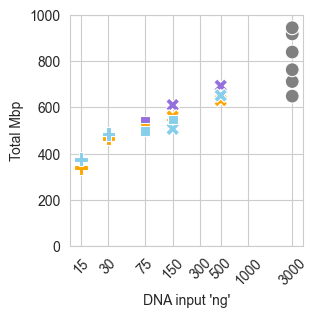

In [244]:
# Impact of DNA input on total yield for EED
plt.figure(figsize=(3, 3))
ax=sns.scatterplot(data=eed_nt_sort, 
                   x="dna_input_ng", 
                   y="sub100k_number_of_Mbp", 
                   hue="mastermix", 
                   style="longplex_rxn2",
                   s=100,
                   palette=custom_colors,legend=False)
ax.set(xlabel="DNA input 'ng'")
ax.set_xscale("log")
ax.set(ylabel="Total Mbp")
plt.xticks(
   ([15,30,75,150,300,500,1000,3000]),
    ["15","30","75","150","300","500","1000","3000"]
)
plt.ylim(0,1000)
plt.xticks(rotation=45, ha="center")
plt.show
plt.savefig("../Figures/EED_dna~Mbp.png", dpi=300, bbox_inches='tight')

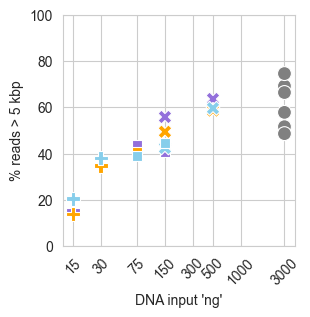

In [222]:
# Impact of DNA input on % reads greater than 5 kb for EED
plt.figure(figsize=(3, 3))
ax=sns.scatterplot(data=eed_nt_sort, 
                   x="dna_input_ng", 
                   y="py_100k_Pct_GT_5000", 
                   hue="mastermix", 
                   style="longplex_rxn2",
                   s=100,
                   palette=custom_colors,legend=False)
ax.set(xlabel="DNA input 'ng'")
ax.set_xscale("log")
ax.set(ylabel="% reads > 5 kbp")
plt.xticks(
   ([15,30,75,150,300,500,1000,3000]),
    ["15","30","75","150","300","500","1000","3000"]
)
plt.xticks(rotation=45, ha="center")
plt.ylim(0,100)
plt.show
plt.savefig("../Figures/EED_dna~Pct>5kb.png", dpi=300, bbox_inches='tight')

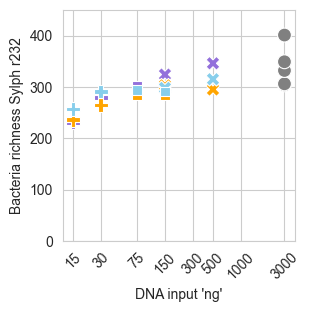

In [220]:
# Impact of DNA input on bacteria richness EED
plt.figure(figsize=(3, 3))
ax=sns.scatterplot(data=eed_nt_sort, 
                   x="dna_input_ng", 
                   y="richness_bacteria_sylph_r232_observed_features", 
                   hue="mastermix", 
                   style="longplex_rxn2",
                   s=100,
                   palette=custom_colors,legend=False)
ax.set(xlabel="DNA input 'ng'")
ax.set_xscale("log")
ax.set(ylabel="Bacteria richness Sylph r232")
plt.xticks(
   ([15,30,75,150,300,500,1000,3000]),
    ["15","30","75","150","300","500","1000","3000"]
)
plt.ylim(0,450)
plt.xticks(rotation=45, ha="center")
plt.show
plt.savefig("../Figures/EED_dna~Bac-richness.png", dpi=300, bbox_inches='tight')

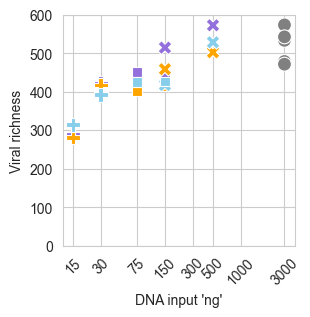

In [265]:
# Impact of DNA input on viral richness EED
plt.figure(figsize=(3, 3))
ax=sns.scatterplot(data=eed_nt_sort, 
                   x="dna_input_ng", 
                   y="richness_viral_sylph_r232_observed_features", 
                   hue="mastermix", 
                   style="longplex_rxn2",
                   s=100,
                   palette=custom_colors,legend=False)
#ax.set(xlabel="DNA input 'ng'")
ax.set_xscale("log")
ax.set(ylabel="Viral richness")
plt.xticks(
   ([15,30,75,150,300,500,1000,3000]),
    ["15","30","75","150","300","500","1000","3000"]
)
ax.set(xlabel="DNA input 'ng'")
plt.ylim(0,600)
plt.xticks(rotation=45, ha="center")
plt.show
plt.savefig("../Figures/EED_dna~viral-richness.png", dpi=300, bbox_inches='tight')